<a href="https://colab.research.google.com/github/asdmhdibcu/fraud-detection-system/blob/main/notebooks/02_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle -q


In [ ]:
import os

# Replace the text inside the quotes with your actual Kaggle info
os.environ['KAGGLE_USERNAME'] = 'asadmehdi096'
os.environ['KAGGLE_KEY'] = 'KGAT_ecfed8945a03e7a67d7fae6a380b9970'

print("Credentials set!")


Credentials set!


In [ ]:
import kagglehub

# This creates the variable 'path'
path = kagglehub.dataset_download("lnasiri007/ieeecis-fraud-detection")



Using Colab cache for faster access to the 'ieeecis-fraud-detection' dataset.


In [ ]:
import pandas as pd
import os

# We use os.path.join to combine the folder 'path' with the filenames
train_trans = pd.read_csv(os.path.join(path, "train_transaction.csv"))
train_id = pd.read_csv(os.path.join(path, "train_identity.csv"))

# Merge and check
df = pd.merge(train_trans, train_id, on='TransactionID', how='left')
print("Successfully loaded and merged!")
print(f"Dataset Path: {path}")
df.head()


Successfully loaded and merged!
Dataset Path: /kaggle/input/ieeecis-fraud-detection


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
# Show percentage of missing values for the first 20 columns
missing_pct = df.isnull().mean() * 100
print("Missing Data Percentage (Top 20 columns):")
print(missing_pct.head(20))


Missing Data Percentage (Top 20 columns):
TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
card1              0.000000
card2              1.512683
card3              0.265012
card4              0.267044
card5              0.721204
card6              0.266028
addr1             11.126427
addr2             11.126427
dist1             59.652352
dist2             93.628374
P_emaildomain     15.994852
R_emaildomain     76.751617
C1                 0.000000
C2                 0.000000
C3                 0.000000
dtype: float64


In [ ]:

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")


Shape: (590540, 434)
Fraud rate: 3.50%


In [ ]:
fraud = df['isFraud'].value_counts()
print(f"Legitimate: {fraud[0]:,}")
print(f"Fraud:      {fraud[1]:,}")
print()
print(f"If your model predicted ZERO fraud on every transaction,")
print(f"it would be {fraud[0]/len(df)*100:.1f}% accurate.")
print(f"That's why accuracy is useless here.")


Legitimate: 569,877
Fraud:      20,663

If your model predicted ZERO fraud on every transaction,
it would be 96.5% accurate.
That's why accuracy is useless here.


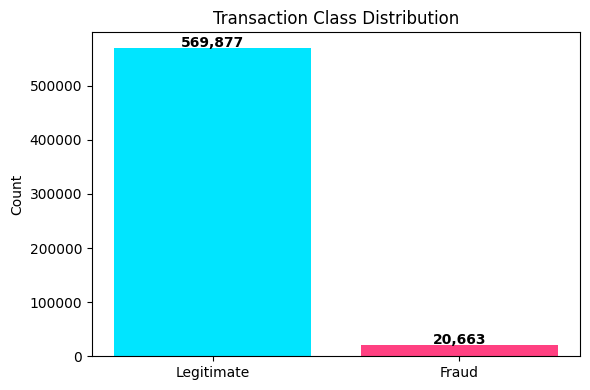

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'],
       [fraud[0], fraud[1]],
       color=['#00E5FF', '#FF4081'])
ax.set_title('Transaction Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate([fraud[0], fraud[1]]):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

print(f"Columns WITH missing values: {len(null_pct)}")
print(f"Columns with MORE THAN 50% missing: {(null_pct > 50).sum()}")
print()
print("Top 10 worst columns:")
print(null_pct.head(10).round(1).to_string())


Columns WITH missing values: 414
Columns with MORE THAN 50% missing: 214

Top 10 worst columns:
id_24    99.2
id_25    99.1
id_07    99.1
id_08    99.1
id_21    99.1
id_26    99.1
id_27    99.1
id_23    99.1
id_22    99.1
dist2    93.6


In [ ]:
import numpy as np

fraud_amt = df[df['isFraud']==1]['TransactionAmt']
legit_amt = df[df['isFraud']==0]['TransactionAmt']

print("FRAUD transactions:")
print(f"  Median: ${fraud_amt.median():.2f}")
print(f"  Mean:   ${fraud_amt.mean():.2f}")
print(f"  Max:    ${fraud_amt.max():.2f}")
print()
print("LEGITIMATE transactions:")
print(f"  Median: ${legit_amt.median():.2f}")
print(f"  Mean:   ${legit_amt.mean():.2f}")
print(f"  Max:    ${legit_amt.max():.2f}")


FRAUD transactions:
  Median: $75.00
  Mean:   $149.24
  Max:    $5191.00

LEGITIMATE transactions:
  Median: $68.50
  Mean:   $134.51
  Max:    $31937.39


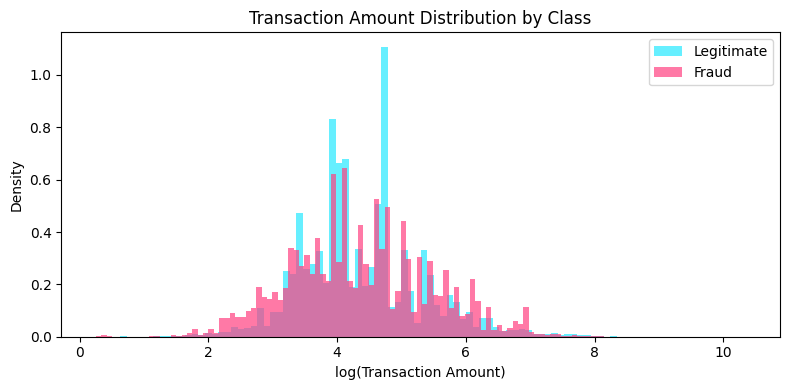

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(legit_amt), bins=100, alpha=0.6,
        color='#00E5FF', label='Legitimate', density=True)
ax.hist(np.log1p(fraud_amt), bins=100, alpha=0.7,
        color='#FF4081', label='Fraud', density=True)
ax.set_xlabel('log(Transaction Amount)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution by Class')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("=" * 45)
print("EDA SUMMARY — Day 1")
print("=" * 45)
print(f"Total transactions:        {len(df):,}")
print(f"Total features:            {df.shape[1]}")
print(f"Fraud rate:                {df['isFraud'].mean()*100:.2f}%")
print(f"Columns with nulls:        {(df.isnull().sum()>0).sum()}")
print(f"Columns >50% null:         {(df.isnull().mean()>0.5).sum()}")
print()
print("DECISIONS MADE TODAY:")
print("  1. Metric = AUC-ROC, NOT accuracy")
print("  2. Missing values → fill with -999")
print("  3. TransactionAmt → log transform")
print("  4. Class imbalance → handle in model training")
print()
print("NEXT SESSION: Feature Engineering")


EDA SUMMARY — Day 1
Total transactions:        590,540
Total features:            434
Fraud rate:                3.50%
Columns with nulls:        414
Columns >50% null:         214

DECISIONS MADE TODAY:
  1. Metric = AUC-ROC, NOT accuracy
  2. Missing values → fill with -999
  3. TransactionAmt → log transform
  4. Class imbalance → handle in model training

NEXT SESSION: Feature Engineering


In [ ]:
print("BEFORE log transform:")
print(f"  Min:    ${df['TransactionAmt'].min():.2f}")
print(f"  Median: ${df['TransactionAmt'].median():.2f}")
print(f"  Max:    ${df['TransactionAmt'].max():.2f}")
print(f"  Std:    ${df['TransactionAmt'].std():.2f}")
print()
print("The max is thousands of times larger than the median.")
print("This extreme skew hurts model training.")
print("Log transform compresses the scale.")


BEFORE log transform:
  Min:    $0.25
  Median: $68.77
  Max:    $31937.39
  Std:    $239.16

The max is thousands of times larger than the median.
This extreme skew hurts model training.
Log transform compresses the scale.


In [ ]:
# log1p means log(1 + x)
# We use 1+ because log(0) is undefined — this handles zero-value transactions safely
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

print("AFTER log transform:")
print(f"  Min:    {df['TransactionAmt_log'].min():.4f}")
print(f"  Median: {df['TransactionAmt_log'].median():.4f}")
print(f"  Max:    {df['TransactionAmt_log'].max():.4f}")
print(f"  Std:    {df['TransactionAmt_log'].std():.4f}")
print()
print("Std dropped dramatically — values are now much closer together.")
print("This makes gradient descent and tree splits more effective.")


AFTER log transform:
  Min:    0.2239
  Median: 4.2452
  Max:    10.3716
  Std:    0.9372

Std dropped dramatically — values are now much closer together.
This makes gradient descent and tree splits more effective.


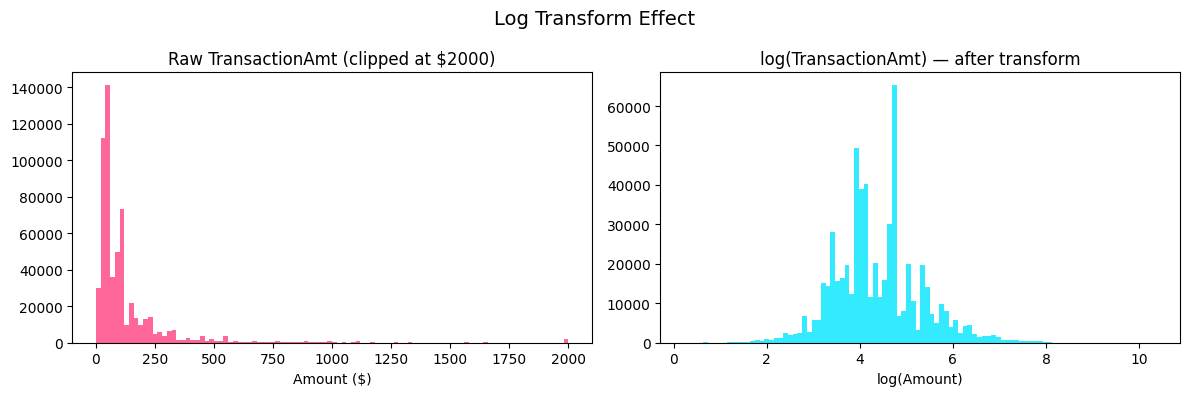

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['TransactionAmt'].clip(upper=2000),
             bins=100, color='#FF4081', alpha=0.8)
axes[0].set_title('Raw TransactionAmt (clipped at $2000)')
axes[0].set_xlabel('Amount ($)')

axes[1].hist(df['TransactionAmt_log'],
             bins=100, color='#00E5FF', alpha=0.8)
axes[1].set_title('log(TransactionAmt) — after transform')
axes[1].set_xlabel('log(Amount)')

plt.suptitle('Log Transform Effect', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
print("TransactionDT is NOT a real timestamp.")
print("It is seconds elapsed since some reference point.")
print()
print(f"Min value:  {df['TransactionDT'].min():,} seconds")
print(f"Max value:  {df['TransactionDT'].max():,} seconds")
print(f"Range:      {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400:.0f} days of data")
print()
print("We extract RELATIVE time patterns — hour of day, day of week.")
print("Fraudsters operate at specific times. Night hours have different fraud rates.")


TransactionDT is NOT a real timestamp.
It is seconds elapsed since some reference point.

Min value:  86,400 seconds
Max value:  15,811,131 seconds
Range:      182 days of data

We extract RELATIVE time patterns — hour of day, day of week.
Fraudsters operate at specific times. Night hours have different fraud rates.


In [ ]:
# 3600 seconds in an hour, 86400 seconds in a day
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  = (df['TransactionDT'] // 86400) % 7

print("Time features created.")
print(f"Hour range: {df['hour'].min()} to {df['hour'].max()}")
print(f"Day range:  {df['day'].min()} to {df['day'].max()}")


Time features created.
Hour range: 0 to 23
Day range:  0 to 6


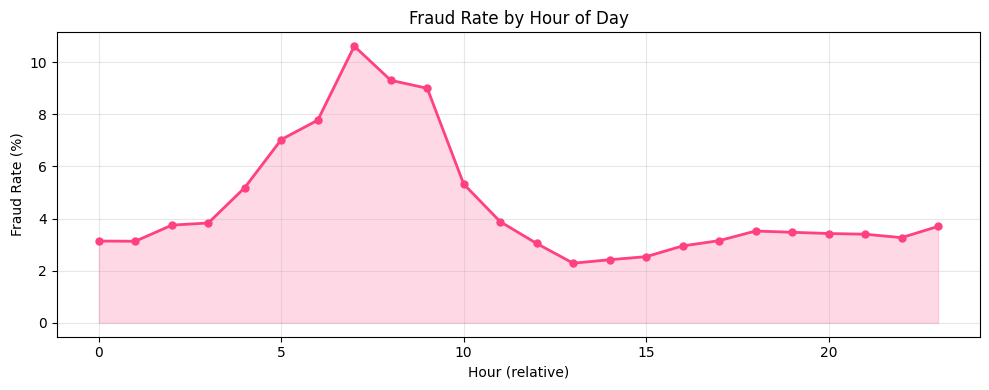

Highest fraud rate at hour: 7
Fraud rate at peak hour:    10.61%
Overall fraud rate:         3.50%


In [ ]:
hourly_fraud_rate = df.groupby('hour')['isFraud'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_fraud_rate.index, hourly_fraud_rate.values,
        color='#FF4081', linewidth=2, marker='o', markersize=5)
ax.fill_between(hourly_fraud_rate.index, hourly_fraud_rate.values,
                alpha=0.2, color='#FF4081')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xlabel('Hour (relative)')
ax.set_ylabel('Fraud Rate (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peak_hour = hourly_fraud_rate.idxmax()
print(f"Highest fraud rate at hour: {peak_hour}")
print(f"Fraud rate at peak hour:    {hourly_fraud_rate[peak_hour]:.2f}%")
print(f"Overall fraud rate:         {df['isFraud'].mean()*100:.2f}%")


In [ ]:
print("Some columns have >30% missing values.")
print("Instead of just filling them, we also CREATE a binary flag.")
print()
print("Example:")
print("  id_01 is missing → id_01_missing = 1")
print("  id_01 has a value → id_01_missing = 0")
print()
print("This lets the model learn TWO things separately:")
print("  1. The actual value of id_01 when present")
print("  2. The fact that it was missing at all")
print()

# Find columns with significant missingness
high_null_cols = df.columns[df.isnull().mean() > 0.3].tolist()
print(f"Columns with >30% nulls: {len(high_null_cols)}")
print("Creating null flags for these...")

for col in high_null_cols:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

new_flag_cols = [c for c in df.columns if c.endswith('_missing')]
print(f"Created {len(new_flag_cols)} null flag features.")


Some columns have >30% missing values.
Instead of just filling them, we also CREATE a binary flag.

Example:
  id_01 is missing → id_01_missing = 1
  id_01 has a value → id_01_missing = 0

This lets the model learn TWO things separately:
  1. The actual value of id_01 when present
  2. The fact that it was missing at all

Columns with >30% nulls: 232
Creating null flags for these...
Created 232 null flag features.


In [ ]:
print("FREQUENCY ENCODING:")
print()
print("A card number that appears 1000 times is suspicious.")
print("A card number that appears 2 times is normal.")
print("The COUNT of appearances is itself a fraud signal.")
print()
print("We replace each card value with HOW OFTEN it appears in the data.")
print("This is called frequency encoding.")
print()
print("Example:")
print("  card1 value '4567' appears 850 times → replace with 850")
print("  card1 value '9123' appears 3 times   → replace with 3")


FREQUENCY ENCODING:

A card number that appears 1000 times is suspicious.
A card number that appears 2 times is normal.
The COUNT of appearances is itself a fraud signal.

We replace each card value with HOW OFTEN it appears in the data.
This is called frequency encoding.

Example:
  card1 value '4567' appears 850 times → replace with 850
  card1 value '9123' appears 3 times   → replace with 3


In [ ]:
# Columns to frequency encode
freq_encode_cols = ['card1', 'card2', 'card3', 'card5',
                    'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']

for col in freq_encode_cols:
    if col in df.columns:
        freq_map = df[col].value_counts()
        df[f'{col}_freq'] = df[col].map(freq_map)
        print(f"  {col}_freq created — {freq_map.nunique()} unique values → numeric")

print()
print("Done. Each card/address now has a frequency score.")
print("High frequency = seen many times = model learns what that means for fraud.")


  card1_freq created — 517 unique values → numeric
  card2_freq created — 329 unique values → numeric
  card3_freq created — 58 unique values → numeric
  card5_freq created — 68 unique values → numeric
  addr1_freq created — 96 unique values → numeric
  addr2_freq created — 23 unique values → numeric
  P_emaildomain_freq created — 56 unique values → numeric
  R_emaildomain_freq created — 55 unique values → numeric

Done. Each card/address now has a frequency score.
High frequency = seen many times = model learns what that means for fraud.


In [ ]:
print("Fraud rate by card1 frequency bucket:")

df['card1_freq_bucket'] = pd.cut(df['card1_freq'],
                                  bins=[0, 10, 50, 200, 500, 99999],
                                  labels=['1-10', '11-50', '51-200', '201-500', '500+'])

result = df.groupby('card1_freq_bucket')['isFraud'].mean() * 100
print(result.round(2).to_string())
print()
print("If fraud rate varies significantly across buckets,")
print("frequency is a powerful signal.")


Fraud rate by card1 frequency bucket:
card1_freq_bucket
1-10       2.94
11-50      2.54
51-200     3.47
201-500    3.75
500+       3.68

If fraud rate varies significantly across buckets,
frequency is a powerful signal.


In [ ]:
print("Filling all remaining nulls with -999.")
print()
print("Why -999 and not 0 or mean?")
print("  → 0 could be a real value (zero amount, zero address code)")
print("  → Mean erases the fact that the value was missing")
print("  → -999 is impossible as a real value — tree can split on it cleanly")
print()

# Fill numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(-999)

# Label encode remaining categorical columns
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns...")

le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print("Done. All columns are now numeric.")
print(f"Final dataframe shape: {df.shape}")
print(f"Any nulls remaining: {df.isnull().sum().sum()}")


Filling all remaining nulls with -999.

Why -999 and not 0 or mean?
  → 0 could be a real value (zero amount, zero address code)
  → Mean erases the fact that the value was missing
  → -999 is impossible as a real value — tree can split on it cleanly



NameError: name 'df' is not defined

In [ ]:
original_features = 434
new_features = df.shape[1]

print("=" * 45)
print("FEATURE ENGINEERING SUMMARY — Day 2")
print("=" * 45)
print(f"Original features:         {original_features}")
print(f"Features after engineering: {new_features}")
print(f"New features added:         {new_features - original_features}")
print()
print("Features created:")
print("  ✓ TransactionAmt_log")
print("  ✓ hour, day (from TransactionDT)")
print("  ✓ Null flags for high-missing columns")
print("  ✓ Frequency encoding for card/address columns")
print("  ✓ All nulls filled with -999")
print("  ✓ All categoricals label encoded")
print()
print("Data is now fully numeric and model-ready.")
print("NEXT: Day 3 — Train your first XGBoost model")


In [ ]:
# ============================================================
# FRAUD DETECTION — FULL SETUP + FEATURE ENGINEERING
# Run this one cell at the start of every session
# ============================================================

from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

# --- Mount Drive ---
drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/fraud-detection-system/data/processed.parquet'
os.makedirs('/content/drive/MyDrive/fraud-detection-system/data', exist_ok=True)

# --- Load from Drive if already saved, otherwise build from scratch ---
if os.path.exists(SAVE_PATH):
    df = pd.read_parquet(SAVE_PATH)
    print(f"Loaded from Drive in seconds: {df.shape}")

else:
    print("First time setup — this takes ~2 minutes, never again after this...")

    # Load raw
    transaction = pd.read_csv('train_transaction.csv')
    identity    = pd.read_csv('train_identity.csv')
    df = transaction.merge(identity, on='TransactionID', how='left')

    # Feature engineering
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day']  = (df['TransactionDT'] // 86400) % 7

    high_null_cols = df.columns[df.isnull().mean() > 0.3].tolist()
    for col in high_null_cols:
        df[f'{col}_missing'] = df[col].isnull().astype(int)

    for col in ['card1','card2','card3','card5','addr1','addr2','P_emaildomain','R_emaildomain']:
        if col in df.columns:
            df[f'{col}_freq'] = df[col].map(df[col].value_counts())

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(-999)

    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col].astype(str))

    # Save permanently to Drive
    df.to_parquet(SAVE_PATH, index=False, compression='gzip')
    print(f"Saved to Drive. File size: {os.path.getsize(SAVE_PATH)/1e6:.1f} MB")

print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
print("Ready.")
